# Факторный анализ
**Автор:** Топорова Е.В.  
**Дата:** 08.11.2025

## Цель и задачи работы
Цель: изучение методов факторного анализа. 

Задачи:
1. Выбрать массив данных, описать признаки. 
2. Провести дескриптивный анализ, оценить согласованность выборок с нормальным распределением.
3. Провести корреляционный анализ, сформулировать предположения о наличии скрытых факторов. 
4. Стандартизировать переменные.
5. Определить факторы методом главных компонент или методом главных факторов. 
6. Изменить факторные нагрузки выбранным методом вращения. 
7. Определить количество факторов с помощью критерия каменистой осыпи и критерия Кайзера. 
8. Применить критерий КМО, Бартлетта и др., оценить результаты. 
9. Интерпретировать полученное решение, описать факторы. 

## Описание данных
Для работы был выбран датасет Wine, который содержит результаты химического анализа 178 образцов вин, выращенных в одном и том же регионе Италии, но полученных из трех разных сортов. Анализ определил 13 компонентов, обнаруженных в каждом из трех типов вин.

Датасет содержит следующие признаки:
1. `Alcohol` - содержание алкоголя;
2. `Malic acid` - яблочная кислота;
3. `Ash` - зольность (минеральные вещества, остающиеся после сжигания вина);
4. `Alcalinity of ash` - щелочность золы;
5. `Magnesium` - содержание магния;
6. `Total phenols` - общие фенолы (антиоксиданты, отвечающие за пользу вина для здоровья);
7. `Flavanoids` - флавоноиды (подкласс фенольных соединений, вещества, определяющие терпкость вина);
8. `Nonflavanoid phenols` - нефлавоноидные фенолы (другие типы фенольных соединений, влияющие на долголетие и выдержку вина);
9. `Proanthocyanins` - проантоцианины (особый тип флавоноидов, создающие вяжущее ощущение);
10. `Color intensity` - интенсивность цвета;
11. `Hue` - оттенок;
12. `OD280/OD315 of diluted wines` - показатель концентрации белков и фенольных соединений;
13. `Proline` - пролин (аминокислота, влияющая на стабильность вкуса и аромата).

Исходные данные не содержат пропусков, все переменные являются количественными.

---
## 1 Загрузка данных и знакомство с ними
Загрузим все необходимые библиотеки.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

Зададим названия колонок.

In [2]:
column_names = [
    'Class', 'Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 
    'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols',
    'Proanthocyanins', 'Color_intensity', 'Hue', 
    'OD280_OD315_of_diluted_wines', 'Proline'
]

Загрузим данные.

In [3]:
df = pd.read_csv('wine.data', header=None, names=column_names)

Отберем только признаки, исключив метки класса, они нам не понадобятся.

In [4]:
df_selected = df.iloc[:, 1:]

Познакомимся с данными.

In [5]:
print(df_selected.head())

   Alcohol  Malicacid   Ash  Alcalinity_of_ash  Magnesium  Total_phenols  \
0    14.23       1.71  2.43               15.6        127           2.80   
1    13.20       1.78  2.14               11.2        100           2.65   
2    13.16       2.36  2.67               18.6        101           2.80   
3    14.37       1.95  2.50               16.8        113           3.85   
4    13.24       2.59  2.87               21.0        118           2.80   

   Flavanoids  Nonflavanoid_phenols  Proanthocyanins  Color_intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280_OD315_of_diluted_wines  Proline  
0                        

---
## 2 Предобработка данных
### 2.1 Пропущенные значения
Проверим наличие пропущенных значений.

In [6]:
print('Количество пропущенных значений:\n', df_selected.isnull().sum())

Количество пропущенных значений:
 Alcohol                         0
Malicacid                       0
Ash                             0
Alcalinity_of_ash               0
Magnesium                       0
Total_phenols                   0
Flavanoids                      0
Nonflavanoid_phenols            0
Proanthocyanins                 0
Color_intensity                 0
Hue                             0
OD280_OD315_of_diluted_wines    0
Proline                         0
dtype: int64


Пропущенные значения в данных не найдены.

### 2.2 Дескриптивный анализ
Выведем описательные статистики.

In [7]:
print("Дескриптивный анализ:")

summary = pd.DataFrame({
    "Среднее": df_selected.mean(numeric_only=True),
    "Медиана": df_selected.median(numeric_only=True),
    "Мода": df_selected.mode().iloc[0],
    "Ст. отклонение": df_selected.std(numeric_only=True),
    "Мин": df_selected.min(),
    "Макс": df_selected.max()
})

print(summary.round(2))

Дескриптивный анализ:
                              Среднее  Медиана    Мода  Ст. отклонение  \
Alcohol                         13.00    13.05   12.37            0.81   
Malicacid                        2.34     1.87    1.73            1.12   
Ash                              2.37     2.36    2.28            0.27   
Alcalinity_of_ash               19.49    19.50   20.00            3.34   
Magnesium                       99.74    98.00   88.00           14.28   
Total_phenols                    2.30     2.36    2.20            0.63   
Flavanoids                       2.03     2.13    2.65            1.00   
Nonflavanoid_phenols             0.36     0.34    0.26            0.12   
Proanthocyanins                  1.59     1.56    1.35            0.57   
Color_intensity                  5.06     4.69    2.60            2.32   
Hue                              0.96     0.96    1.04            0.23   
OD280_OD315_of_diluted_wines     2.61     2.78    2.87            0.71   
Proline         

Посмотрим на распределения признаков.

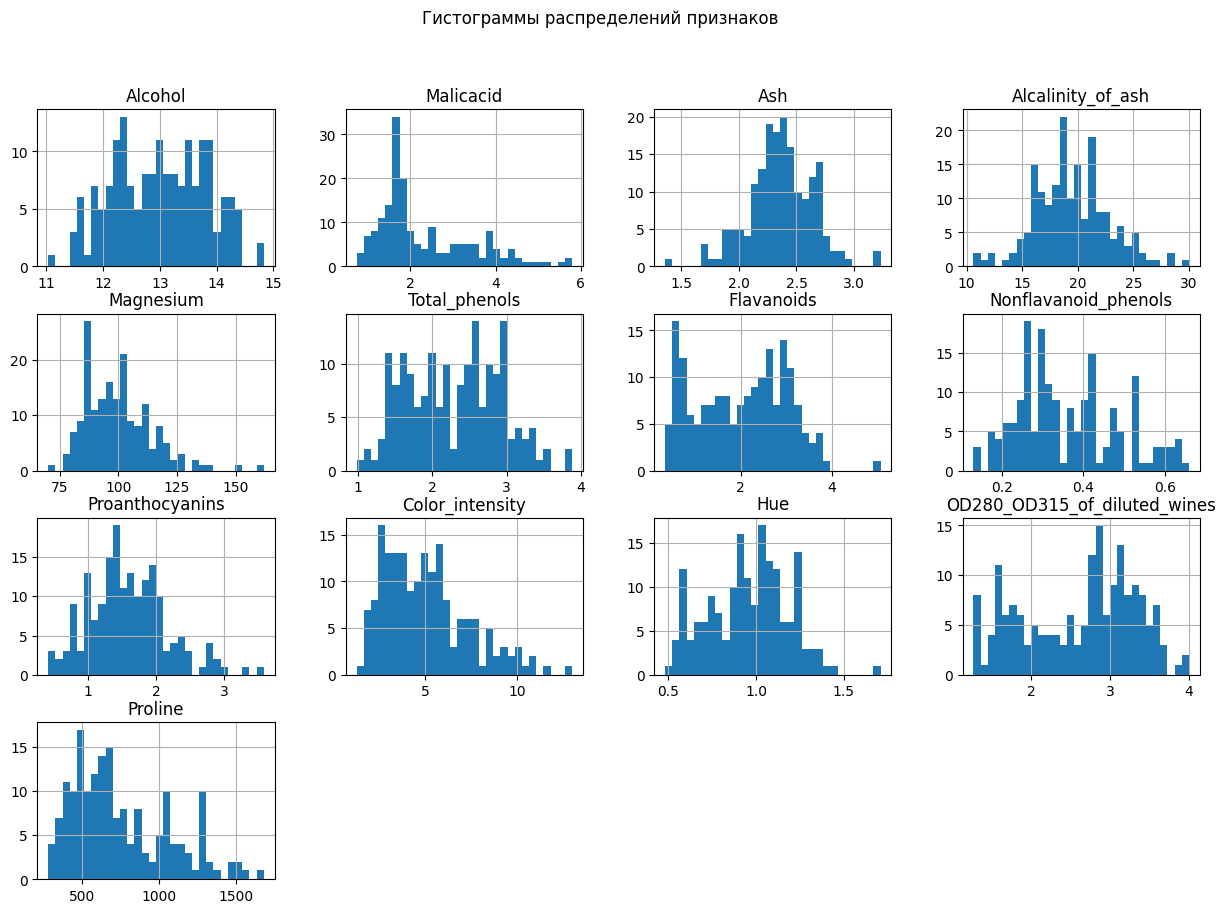

In [8]:
df_selected.hist(bins=30, figsize=(15, 10))
plt.suptitle("Гистограммы распределений признаков")
plt.show()

По гистограммам видно, что распределения многих признаков не согласуются с нормальным (предположить о нормальности можно лишь в случае с `Ash`). Также все признаки имеют разные единицы измерения, средние и стандартные отклонения, поэтому требуется стандартизация.

### 2.3 Стандартизация

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_selected)
df_scaled = pd.DataFrame(X_scaled, columns=df_selected.columns)
print("Данные после стандартизации:")
print(df_scaled.head())

Данные после стандартизации:
    Alcohol  Malicacid       Ash  Alcalinity_of_ash  Magnesium  Total_phenols  \
0  1.518613  -0.562250  0.232053          -1.169593   1.913905       0.808997   
1  0.246290  -0.499413 -0.827996          -2.490847   0.018145       0.568648   
2  0.196879   0.021231  1.109334          -0.268738   0.088358       0.808997   
3  1.691550  -0.346811  0.487926          -0.809251   0.930918       2.491446   
4  0.295700   0.227694  1.840403           0.451946   1.281985       0.808997   

   Flavanoids  Nonflavanoid_phenols  Proanthocyanins  Color_intensity  \
0    1.034819             -0.659563         1.224884         0.251717   
1    0.733629             -0.820719        -0.544721        -0.293321   
2    1.215533             -0.498407         2.135968         0.269020   
3    1.466525             -0.981875         1.032155         1.186068   
4    0.663351              0.226796         0.401404        -0.319276   

        Hue  OD280_OD315_of_diluted_wines   P

Все переменные были стандартизированы с использованием метода Z-score нормализации (StandardScaler в python). Данная процедура обеспечила нулевые средние значения и единичные стандартные отклонения для всех переменных, что необходимо для корректного построения корреляционной матрицы и последующего факторного анализа.

---
## 3 Оценка необходимости проведения факторного анализа
### 3.1 Корреляционный анализ
Проведем корреляционный анализ для выяления зависимостей в данных. Так мы сможем понять, подходит ли данных датасет для факторного анализа.

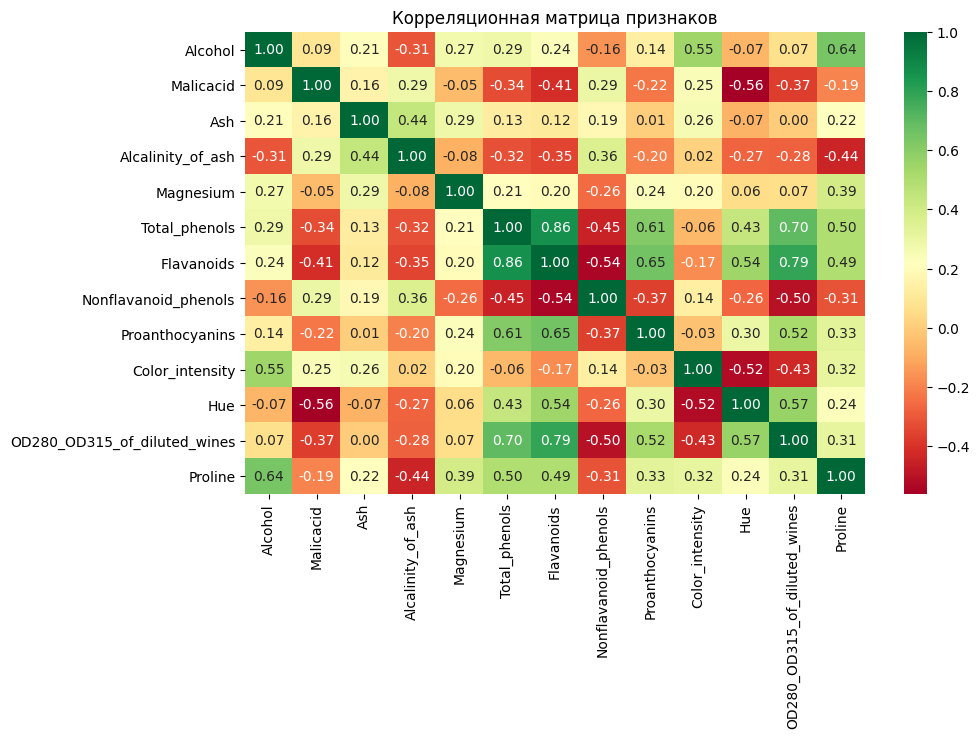

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_scaled.corr(), annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Корреляционная матрица признаков")
plt.show()

По корреляционной матрице видно, что:
1. `Total phenols`, `Flavanoids`, `Proanthocyanins`, `OD280/OD315` обладают высокими корреляциями в пределах от 0.5 до 0.8, что неудивительно, ведь все они измеряют различные аспекты фенольных соединений в вине. Здесь может быть скрытый фактор вроде фенольного профиля.
2. `Alchocol`, `Proline` обладают умеренной корреляцией (0.64). Возможный скрытый фактор - зрелость винограда.
3. `Color intensity`, `Hue` обладают умеренной корреляцией (0.52). Возможно, присутствует скрытый фактор - цветовая характеристика.
4. `Ash` и `Alcalinity of ash` с корреляцией 0.44 отражают минеральный состав вина, который зависит от почвы региона происхождения.
5. `Magnesium` трудно куда-либо отнести, так как он незначительно коррелируют со всеми переменными.

Таким образом, вероятность необходимости проведения факторного анализа существует, но лучше удостовериться в этом с помощью следующих критериев.

### 3.2 Критерий Бартлетта

In [11]:
# Тест сферичности Бартлетта
chi_square_value, p_value = calculate_bartlett_sphericity(df_scaled)
print(f"Тест Бартлетта:")
print(f"  Chi-square: {chi_square_value:.3f}")
print(f"  p-value: {p_value:.3f}")

Тест Бартлетта:
  Chi-square: 1317.181
  p-value: 0.000


Результат теста Бартлетта с p-value < 0.05 говорит о том, что существуют статистически значимые корреляции между переменными, и подтверждает, что корреляционная матрица значимо отличается от единичной, что важно для применения факторного анализа.

### 3.3 Критерий Кайзера-Мейера-Олкина

In [12]:
# KMO тест
kmo_all, kmo_model = calculate_kmo(df_scaled)
print(f"KMO тест: {kmo_model:.3f}")

KMO тест: 0.779


Результат КМО, равный 0.779, указывает на то, что переменные достаточно взаимосвязаны для проведения факторного анализа. 

---
## 4 Факторный анализ
### 4.1 Определение количества факторов
Для начала посмотрим на компоненты и на то, сколько дисперсии исходных данных они выражают.

In [13]:
pca = PCA()
X_pca = pca.fit_transform(df_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
eigenvalues = pca.explained_variance_

pca_results = pd.DataFrame({
    'Компонента': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Доля дисперсии': explained_variance,
    'Накопленная дисперсия': cumulative_variance,
    'Собственное значение': eigenvalues
})

print(pca_results.round(3))

   Компонента  Доля дисперсии  Накопленная дисперсия  Собственное значение
0         PC1           0.362                  0.362                 4.732
1         PC2           0.192                  0.554                 2.511
2         PC3           0.111                  0.665                 1.454
3         PC4           0.071                  0.736                 0.924
4         PC5           0.066                  0.802                 0.858
5         PC6           0.049                  0.851                 0.645
6         PC7           0.042                  0.893                 0.554
7         PC8           0.027                  0.920                 0.350
8         PC9           0.022                  0.942                 0.291
9        PC10           0.019                  0.962                 0.252
10       PC11           0.017                  0.979                 0.227
11       PC12           0.013                  0.992                 0.170
12       PC13           0

#### 4.1.2 Определение факторов методом каменистой осыпи. Критерий Кайзера

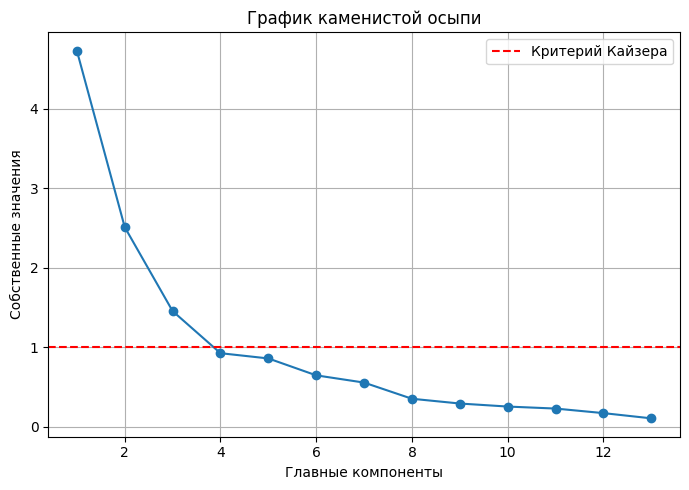

In [14]:
# Критерий каменистой осыпи
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-')
plt.axhline(y=1, color='r', linestyle='--', label='Критерий Кайзера')
plt.xlabel('Главные компоненты')
plt.ylabel('Собственные значения')
plt.title('График каменистой осыпи')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

По графику каменистой осыпи необходимо найти точку излома, после которой значения почти не изменяются. На рисунке видно, что такая точка соответствуют 4 компонентам.

По критерию Кайзера необходимо оставить только те компоненты, собственные значения которых не меньше 1. По таблице 3 и рисунку 5 можно сделать вывод, что нужно оставить лишь 3 компоненты. Однако, стоит заметить, что собственное значение 4 компоненты очень близко к 1.

Несмотря на то, что критерий Кайзера рекомендует 3 компоненты, а критерий КМО - 4, для практических целей было выбрано 5 компонент, объясняющих 80.2% исходной информации. Это обеспечит более качественную интерпретацию факторов при приемлемом уровне сокращения размерности.

#### 4.1.3 Определение факторов методом главных компонент

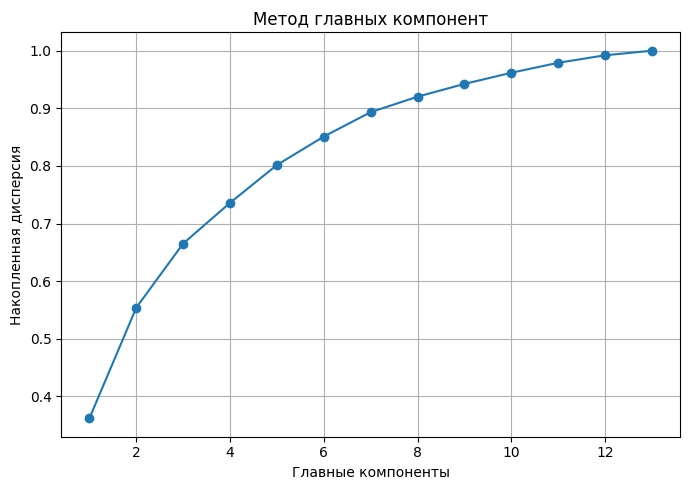

In [15]:
# График накопленной дисперсии
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Главные компоненты')
plt.ylabel('Накопленная дисперсия')
plt.title('Метод главных компонент')
plt.grid(True)
plt.tight_layout()
plt.show()

Необходимо выбрать такое количество компонент, чтобы они объясняли не менее 80-95% исходной информации. В нашем случае это 5 компонент.

### 4.2 Запуск моделей
Чтобы получить независимые интерпретируемые компоненты, выявить четкую факторную структуру, был выбран метод вращения Varimax. Такой метод подходит для рассматриваемого датасета, так как химические показатели могут рассматриваться как относительно независимые компоненты.

#### 4.2.1 Матрица факторных нагрузок до применения вращения
Выведем матрицу нагрузок до применения вращения.

In [16]:
n_factors = 5

# Факторный анализ без вращения
fa_no_rotation = FactorAnalyzer(n_factors=n_factors, rotation=None)
fa_no_rotation.fit(df_scaled)
loadings_no_rotation = fa_no_rotation.loadings_

print("Матрица нагрузок до применения вращения:")
loadings_df_no_rot = pd.DataFrame(
    loadings_no_rotation,
    index=df_scaled.columns,
    columns=[f'Factor{i+1}' for i in range(n_factors)]
)
print(loadings_df_no_rot.round(2))

Матрица нагрузок до применения вращения:
                              Factor1  Factor2  Factor3  Factor4  Factor5
Alcohol                          0.30     0.69    -0.26     0.17     0.15
Malicacid                       -0.47     0.28     0.05     0.13    -0.18
Ash                              0.01     0.52     0.74     0.12     0.20
Alcalinity_of_ash               -0.49     0.01     0.61     0.06    -0.09
Magnesium                        0.32     0.52     0.17    -0.75    -0.14
Total_phenols                    0.85     0.09     0.12     0.19    -0.14
Flavanoids                       0.94    -0.02     0.15     0.18    -0.13
Nonflavanoid_phenols            -0.58     0.04     0.15     0.11     0.21
Proanthocyanins                  0.62     0.04     0.09     0.06    -0.25
Color_intensity                 -0.18     0.76    -0.18     0.14    -0.03
Hue                              0.65    -0.44     0.13    -0.16     0.47
OD280_OD315_of_diluted_wines     0.80    -0.26     0.16     0.12    -0.

#### 4.2.2 Матрица нагрузок после Varimax вращения
Выведем матрицу нагрузок после применения вращения.

In [17]:
# Факторный анализ с Varimax вращением
fa_varimax = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa_varimax.fit(df_scaled)
loadings_varimax = fa_varimax.loadings_

print("\nМатрица нагрузок после Varimax вращения:")
loadings_df_varimax = pd.DataFrame(
    loadings_varimax,
    index=df_scaled.columns,
    columns=[f'Factor{i+1}' for i in range(n_factors)]
)
print(loadings_df_varimax.round(2))


Матрица нагрузок после Varimax вращения:
                              Factor1  Factor2  Factor3  Factor4  Factor5
Alcohol                          0.15     0.80    -0.12     0.01     0.08
Malicacid                       -0.27     0.02    -0.50     0.18    -0.04
Ash                              0.06     0.23    -0.04     0.89     0.14
Alcalinity_of_ash               -0.23    -0.38    -0.25     0.61    -0.03
Magnesium                        0.15     0.21     0.01     0.10     0.96
Total_phenols                    0.83     0.24     0.20     0.03     0.03
Flavanoids                       0.91     0.18     0.30     0.02     0.02
Nonflavanoid_phenols            -0.52    -0.08    -0.14     0.29    -0.20
Proanthocyanins                  0.66     0.09     0.07    -0.03     0.12
Color_intensity                 -0.16     0.61    -0.50     0.12     0.09
Hue                              0.31    -0.05     0.88    -0.03     0.01
OD280_OD315_of_diluted_wines     0.77    -0.05     0.38    -0.04    -0

До применения вращения видна сложная структура, когда переменные распределены по нескольким факторам, после - получено более четкое разделение.

#### 4.2.3 Диаграммы рассеивания факторов
Для оценки качества вращения необходимо обратиться к диаграммам рассеивания факторов.

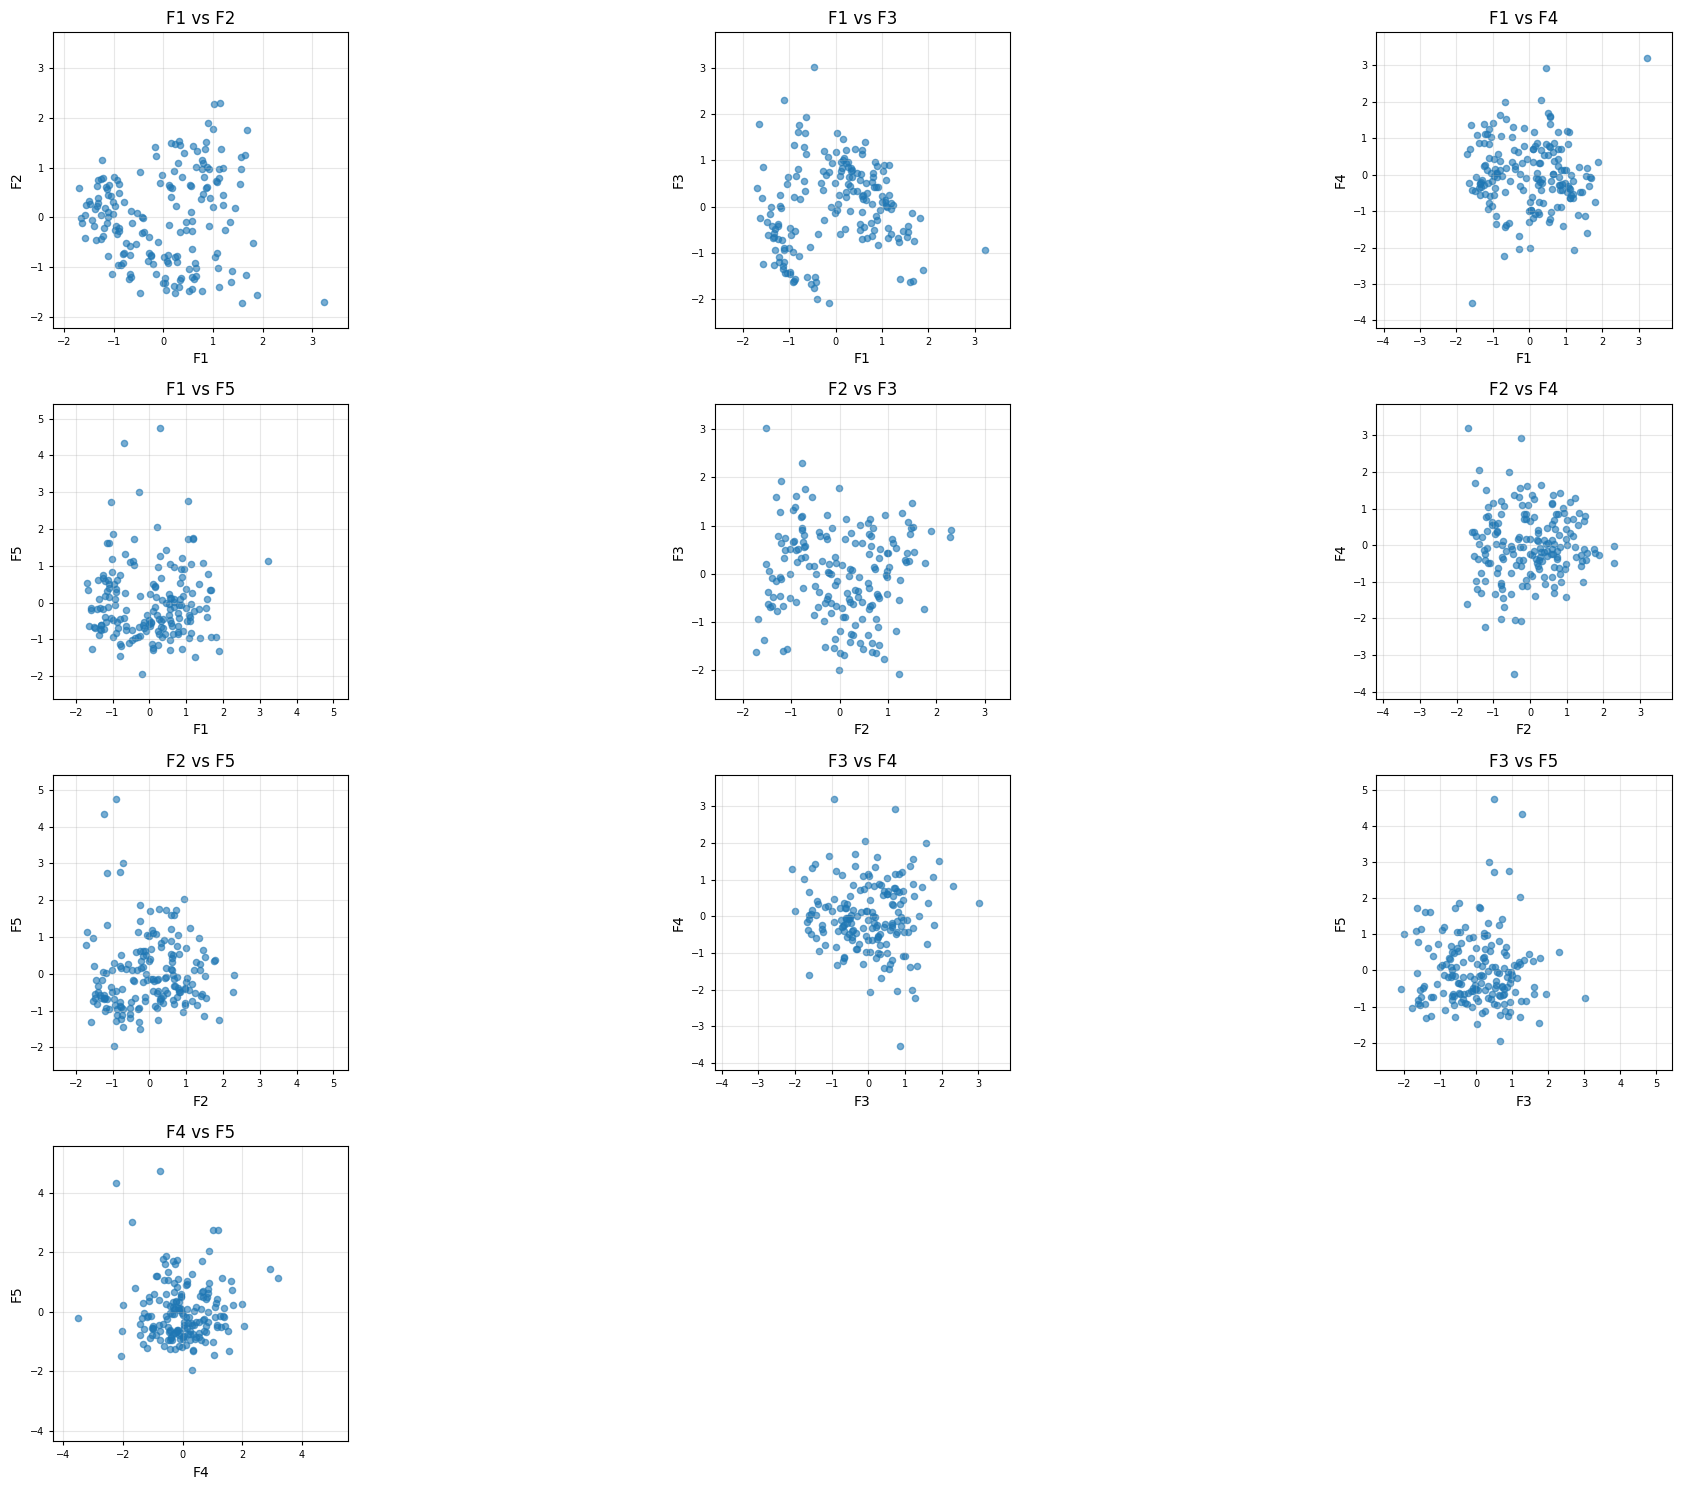

In [18]:
# Диаграммы рассеивания
factor_scores = fa_varimax.transform(df_scaled)
n_factors = factor_scores.shape[1]
n_plots = n_factors * (n_factors - 1) // 2

plt.figure(figsize=(20, 15))
plot_num = 1
for i in range(n_factors):
    for j in range(i + 1, n_factors):
        ax = plt.subplot((n_plots + 2) // 3, 3, plot_num)
        
        plt.scatter(factor_scores[:, i], factor_scores[:, j], alpha=0.6, s=20)
        
        x_data = factor_scores[:, i]
        y_data = factor_scores[:, j]
        
        data_min = min(x_data.min(), y_data.min())
        data_max = max(x_data.max(), y_data.max())
        margin = 0.1 * (data_max - data_min)
        plot_min = data_min - margin
        plot_max = data_max + margin
        
        plt.xlim(plot_min, plot_max)
        plt.ylim(plot_min, plot_max)
        ax.set_aspect('equal')

        plt.xlabel(f'F{i+1}')
        plt.ylabel(f'F{j+1}')
        plt.title(f'F{i+1} vs F{j+1}')
        plt.grid(True, alpha=0.3)
        
        ax.tick_params(axis='both', which='major', labelsize=7, length=3)
        
        plot_num += 1

plt.tight_layout()
plt.show()

В основном, все диаграммы представляют собой равномерные «облака» точек, что говорит об отсутствии корреляции между полученными факторами. На некоторых диаграммах видно небольшое количество выбросов, но их наличие не нарушает общую структуру распределения и не свидетельствует о проблемах с факторной моделью.

---
## 5 Интерпретация результатов
Для оценки результатов выведем матрицу факторных нагрузок после Varimax вращения в более удобном виде.

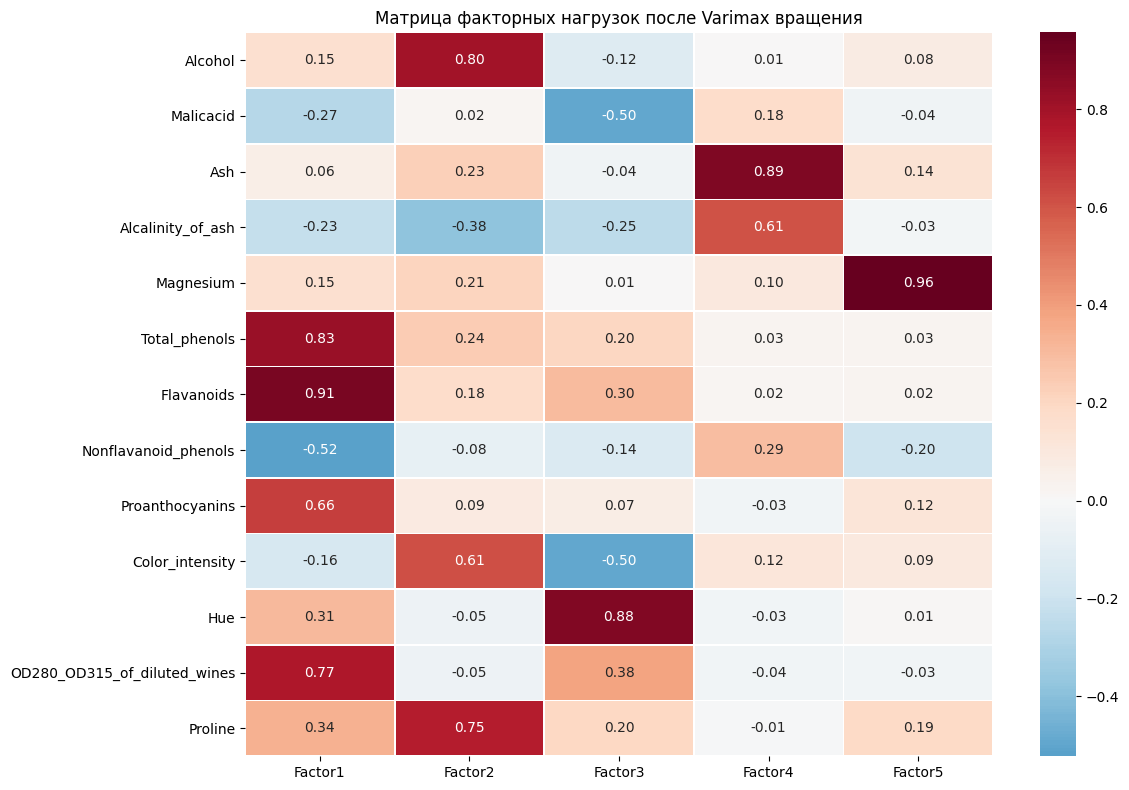

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(loadings_df_varimax, annot=True, cmap="RdBu_r", center=0, 
            fmt=".2f", linewidths=0.5)
plt.title("Матрица факторных нагрузок после Varimax вращения")
plt.tight_layout()
plt.show()

По матрице факторных нагрузок видно, что было получено 5 факторов, которые можно охарактеризовать следующим образом:
1. Фенольный профиль - `Flavanoids` (0.91), `Total_phenols` (0.83), `OD280/OD315` (0.77), `Proanthocyanins` (0.66) - соединения, определяющие терпкость и сложность вкуса.
2. Зрелость винограда - `Alchocol` (0.8), `Proline` (0.75), `Color_intensity` (0.61) - крепость и структура вина, связанные со зрелостью винограда.
3. Цветовые характеристики - `Hue` (0.88), `Color_intensity` (-0.5), `Malic acid` (-0.5) - цветовой баланс, связанный с кислотностью.
4. Минеральный состав - `Ash` (0.89), `Alcalinity_of_ash` (0.61) - зольность и щелочность вин.
5. Магниевый компонент - `Magnesium` (0.96) - содержание магния как независимый показатель.

Таким образом, применение факторного анализа позволило сократить размерность исходных данных с 13 переменных до 5 скрытых факторов, сохраняя 80% исходной информации и обеспечивая содержательную интерпретация химического состава вин.